In [1]:
# Boyko, J.D., O’Meara, B.C. and Beaulieu, J.M. (2023) “A novel method for jointly modeling the evolution of discrete and continuous traits,” Evolution, 77(3), pp. 836–851.
# Available at: https://doi.org/10.1093/evolut/qpad002.
# try and reproduce the analyses of the above paper to get comfortable with the OUwie stuff

In [8]:
# code repo - https://github.com/tncvasconcelos/seed_dispersal
# code repo - https://github.com/jboyko/2020_houwie
# look up https://github.com/jboyko/2020_houwie/blob/master/04_empirical-seed-dispersal.R for reference

In [67]:
suppressPackageStartupMessages({
    library("ape")
    library("phytools")
    library("nlme")
    library("corHMM")
    library("geiger")
    library("mkcor")
    library("OUwie")
    library("reshape2")
    library("ggplot2")
})

stopifnot(packageVersion("OUwie") == "2.16")
stopifnot(packageVersion("corHMM") == "2.8")

source("../hOUwieNode.R") # from https://raw.githubusercontent.com/jboyko/2020_houwie/refs/heads/master/hOUwieNode.R

In [2]:
# pick family Ericaceae

# # we don't want the other unnecessary columns
# fruits <- read.csv("../R/thirdparty/seed_dispersal/trait_dataa/Ericaceae_trait_dataa.csv")[, c("Species", "Fruit_type")]
# fruits <- fruits[fruits$Fruit_type == "Fleshy" | fruits$Fruit_type == "Dry", ] # drop the rows that do not have actual data for life form
# # Fruit_type is a binary discrete categorical trait with values Fleshy and Dry
# fruits$Fruit_type |> table()
# dim(fruits ) # 444 species

# continuous traits
climate <- read.csv("../../R/thirdparty/seed_dispersal/trait_data/Ericaceae_niche.csv") # looks like this too has the fruit type info embedded
climate$Fruit_type |> table()


   Dry Fleshy 
   158    151 

In [3]:
# load in the phylogenetic tree for Ericaceae
tree <- ape::read.tree("../../R/thirdparty/seed_dispersal/trees/Ericaceae_Schwery_etal_2015.tre")
stopifnot(ape::is.binary(tree))

In [4]:
# drop the species in the dataaset if they are not in the phylogenetic tree
species <- intersect(tree$tip.label, climate$species) # 309 species
indices <- match(species, climate$species)
data <- climate[indices, c("species", "Fruit_type", "mean_aridity", "se_aridity")]

In [5]:
# the standard error column has 43 NAs???
colSums(is.na(data))

species   Fruit_type mean_aridity   se_aridity 
           0            0            0           43

In [6]:
# update these with the mean of the se_aridity column (????)
data$se_aridity[is.na(data$se_aridity)] <- mean(data$se_aridity, na.rm = TRUE)

In [7]:
stopifnot(sum(is.na(data)) == 0) # make sure no NAs in the data
stopifnot(length(intersect(data$species, tree$tip.label)) == length(indices)) # make sure that we only have species for which there's data in the phylogeny

In [8]:
# see the mean of mean_aridity, grouped by fruit type
lapply(split(data, ~Fruit_type), FUN = function(df) { c(mean(df$mean_aridity), mean(df$se_aridity)) }) |> as.data.frame(row.names=c("mean", "SE"))

,Dry,Fleshy
,<dbl>,<dbl>
mean,9.32022626,8.89519592
SE,0.08538976,0.09167124


In [9]:
# drop the unnecessary species from the phylogeny
species_to_drop_from_tree <- setdiff(tree$tip.label, species) # order of the args matters here!!!
pruned_tree <- ape::drop.tip(phy = tree, tip = species_to_drop_from_tree)
stopifnot(all.equal(data$species, pruned_tree$tip.label)) # make sure the order of species match in data & the phylogeny

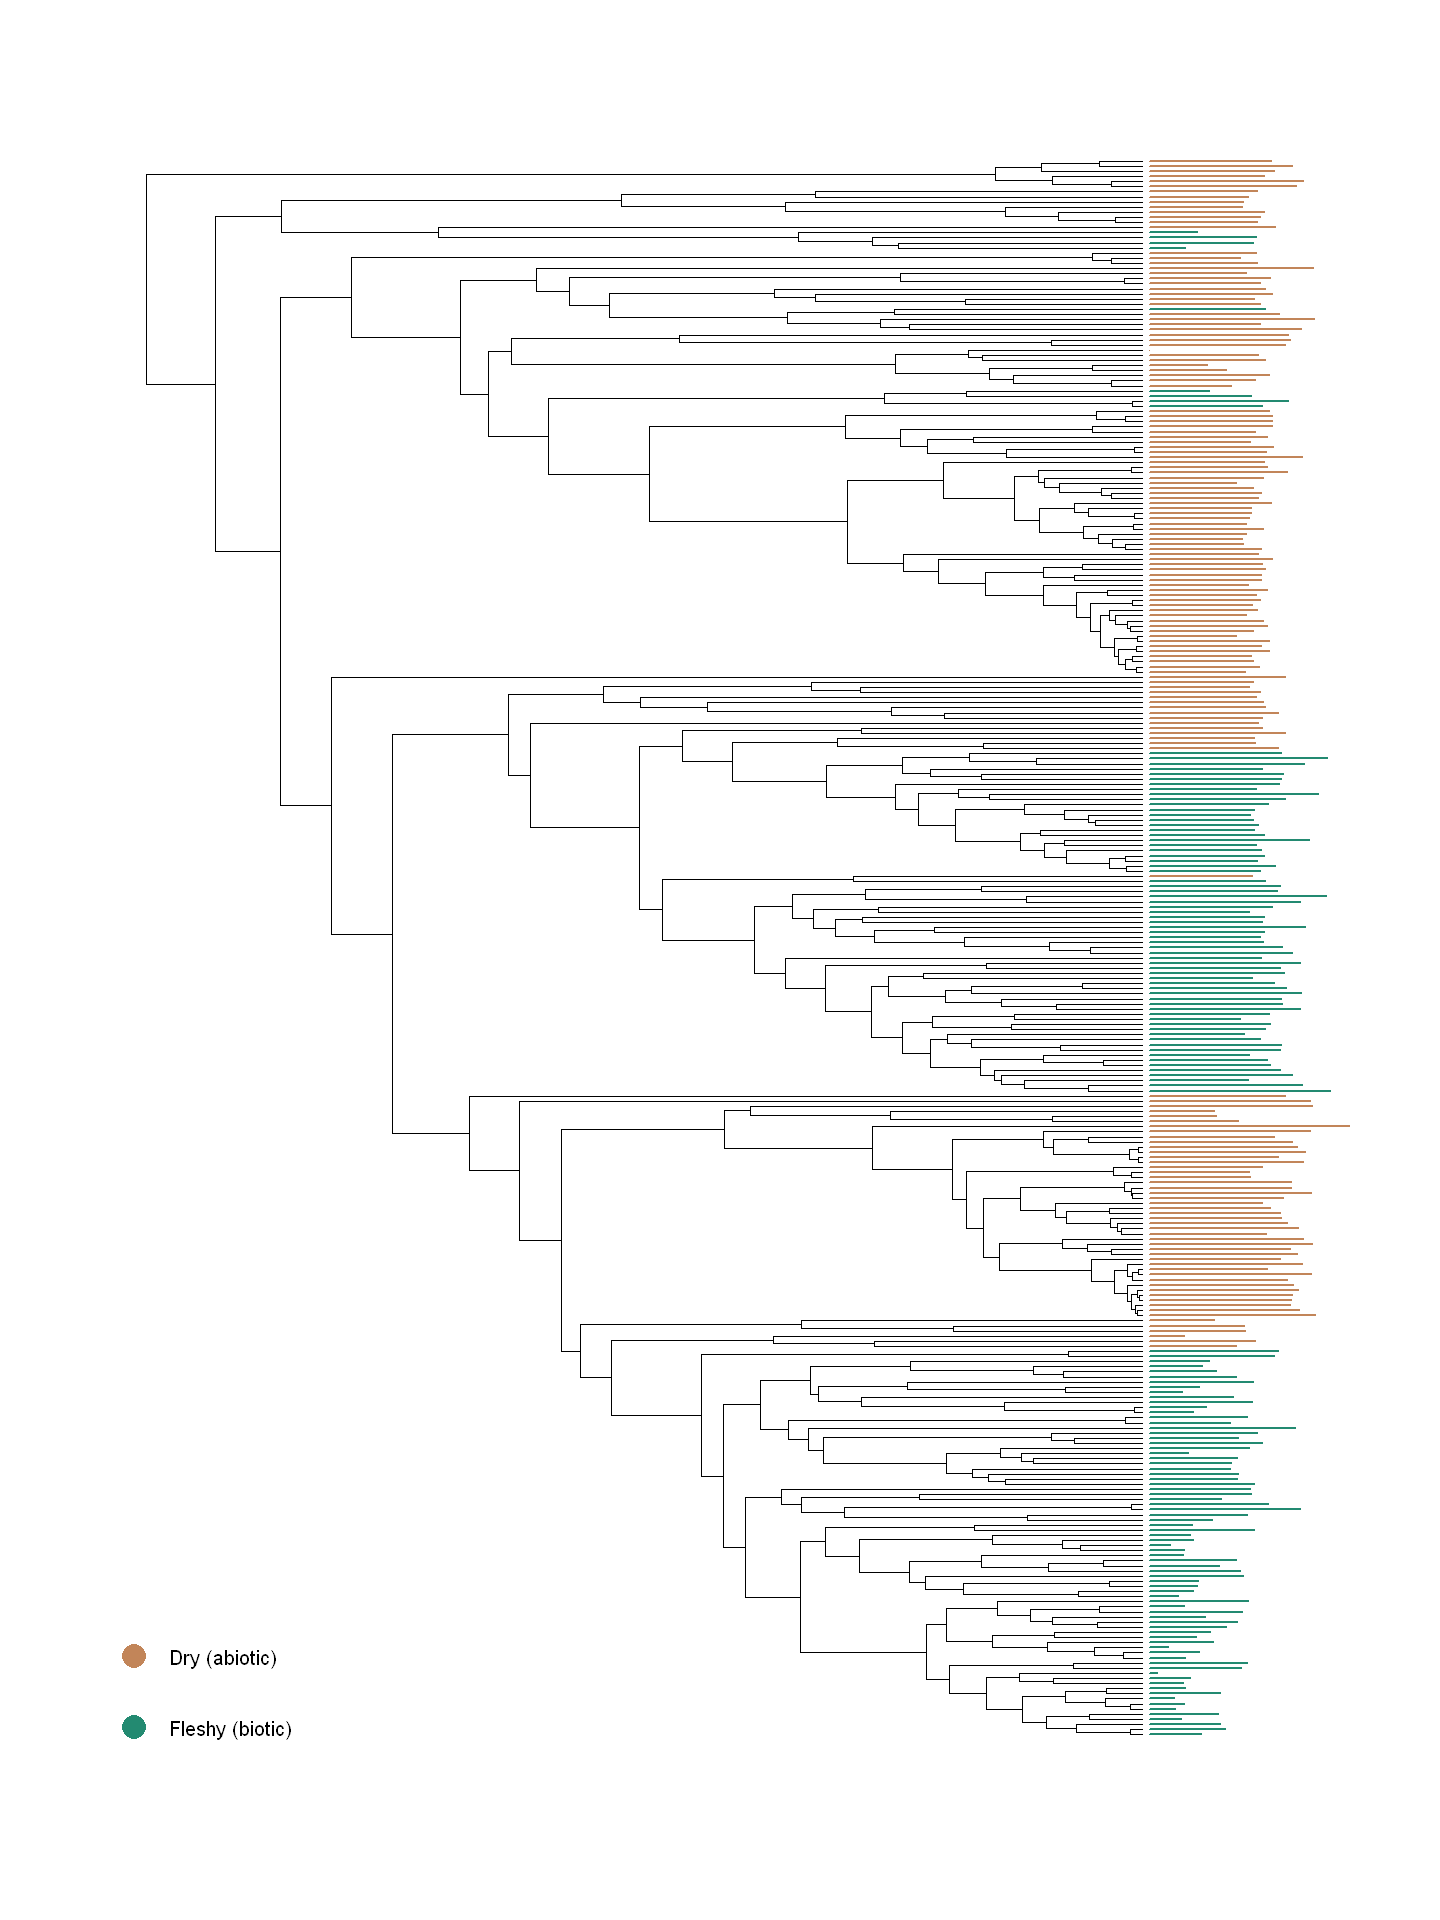

In [10]:
# visualize the pruned phylogeny with aridity index
options(repr.plot.width = 12, repr.plot.height = 16)
cols <- c("#C28559", "#238A71")

tmax <- max(ape::branching.times(pruned_tree))
plot(pruned_tree, show.tip.label = FALSE, x.lim = c(0, tmax + 0.2 * tmax))
start <- tmax + (0.0075 * tmax) # position to start the aridity index lines
aridity_index <- data$mean_aridity
# rescale the aridity index so the lines don't look too wide
scaled_aridity_index <- (aridity_index - min(aridity_index)) / max(aridity_index - min(aridity_index))
multiplier <- tmax * 0.2
for(i in 1:length(scaled_aridity_index)){
    lines(list(x = c(start, start + scaled_aridity_index[i] * multiplier), y = c(i, i)), col = cols[ifelse(data$Fruit_type[i] == "Dry", 1, 2)], lwd = 2)
}
legend("bottomleft", legend = c("Dry (abiotic)","Fleshy (biotic)"), pch=20, col = cols, bty='n', pt.cex=4)
# cool, Fig 5 on the paper is actually of mean aridity BUT IT IS NOT IDENTICAL TO OUR MANUALLY COMPUTED aridity_index????

In [24]:
corHMM::getRateCatMat(length(unique(data$Fruit_type))) # ARD type rate class matrix

,R1,R2
R1,0,2
R2,1,0


In [17]:
# has 2 rate categories (R1, R2) and each category has two states (1, 2)

# corHMM::getFullMat combines several index matrices which describe transitions between observed states into output a single index matrix for use in corHMM

# StateMats - list of index matrices describing transitions between observed states. each unique number from 1 to n, will be independently estimated. 
# values of 0 are not estimated. matrix entries of the same value are estimated to be the same rate.

# RateClassMat - an optional index matrix which describes how StateMats are related to one another. this will be a matrix of size: length(StateMats) by length(StateMats).
# by default, all transitions between StateMats are allowed and independently estimated.

corHMM::getFullMat(StateMats = list(corHMM::getRateCatMat(2), corHMM::getRateCatMat(2)), RateClassMat = corHMM::getRateCatMat(2))
# here we treat the combinations of rate categories and character states as a multistate character i.e (1, R1) is viewed as a multistate character 
# primary diagonal is zeroed out - self transitions
# seconday diaginal is zeroed out - dual transitions
# and (1, R2) to (1, R1) and (2, R2) to (2, R1) has the same rate class??? BECAUSE EVEN UNDER ARD SITUATION, these two are just R2 to R1 transitions because the character state stays the same, only the rate class 
# changes - hence the identical rate classes!!!

,"(1,R1)","(2,R1)","(1,R2)","(2,R2)"
"(1,R1)",0,2,6,0
"(2,R1)",1,0,0,6
"(1,R2)",5,0,0,4
"(2,R2)",0,5,3,0


In [12]:
# character dependent rate category mat => gives a layout for the possible discrete state transitions for a discrete character state with two states e.g. dry & fleshy and only one rate category
# in OUwie, each rate category is represented by a separate process (evolutionary driver)
cd_discrete <- corHMM::getRateCatMat(length(unique(data$Fruit_type))) # ONLY ONE RATE CATEGORY & ARD situation
cd_discrete
#     R1 R2
# R1  0  2
# R2  1  0

,R1,R2
R1,0,2
R2,1,0


In [13]:
# look up https://github.com/thej022214/corHMM/blob/master/vignettes/corHMMv2.1-vignette.pdf for a detailed walkthrough about discrete state transition rate categories

# discrete-character-independent (HMM) drivers of continuous trait evolution
# corHMM::getFullMat combines several index matrices which describe transitions between observed states into output a single index matrix for use in corHMM
cid_discrete <- corHMM::getFullMat(StateMats = list(cd_discrete, cd_discrete), # state transition matrices
                                   RateClassMat = corHMM::getRateCatMat(2)) # rate class matrix
# below is what we got from corHMM::getFullMat
# R1 stands for rate category 1 and R2 for rate category 2
# this rate class matrix disallows dual state transitions (RATE CATEGORY IS TREATED AS PART OF THE MULTISTATE DISCRETE CHARACTER HERE) and represents the ARD situation
#         (1,R1) (2,R1) (1,R2) (2,R2)
# (1,R1)      0      2      6      0
# (2,R1)      1      0      0      6
# (1,R2)      5      0      0      4
# (2,R2)      0      5      3      0

# when dual transitions are allowed (cross rate category transitions and discrete state transitions happening simultaneously), there will be 4 x 4 - 4 = 12 transitions possible
# hypotheticaL rate class matrix under such case - ARD situation
#       (1,R1) (2,R1) (1,R2) (2,R2)
# (1,R1)    0      5      9     13
# (2,R1)    2      0     10     14
# (1,R2)    3      7      0     15
# (2,R2)    4      8     12      0

# RATE CLASS MATRICES AND TRANSITION RATE MATRICES ARE READ FROM ROW TO COLUMN

# but what we saw was different from this! this is because corHMM makes a simplyfying assumption that when a change in one discrete character is occurring another in the second discrete character 
# cannot occur simultaneously. i.e (1, R1) can transition directly to (1, R2) or (2, R1) but not to (2, R2) - prohibited dual transitions;
# in order for state (1, R1) to transition to (2, R2), it will have to go through either (1, R2) or (2, R1)
# SO OUR RATE CLASS MATRIX NOT ONLY HAS ITS PRIMARY DIAGONAL (SELF TRANSITIONS) ZEROED OUT BUT ALSO HAS ITS SECONDARY DIAGONAL (DUAL TRANSITIONS) ZEROED OUT
# again, look up the corHMM package vignette for a comprehensive explanation

cid_discrete

,"(1,R1)","(2,R1)","(1,R2)","(2,R2)"
"(1,R1)",0,2,6,0
"(2,R1)",1,0,0,6
"(1,R2)",5,0,0,4
"(2,R2)",0,5,3,0


In [45]:
corHMM::equateStateMatPars(StateMat = cid_discrete, ParsList = list(c(1, 3), c(2, 4))) # replacing zeroes with NAs???s

,"(1,R1)","(2,R1)","(1,R2)","(2,R2)"
"(1,R1)",NA,4,2,NA
"(2,R1)",3,NA,NA,2
"(1,R2)",1,NA,NA,4
"(2,R2)",NA,1,3,NA


In [18]:
# use the equateStateMatPars() function to create a "SYM" flavoured rate class matrix, in which the ﬁrst argument is the rate class matrix being modiﬁed (i.e. a rate.mat object)
# and second argument is list of the parameters to be equated.
# one thing to note is that you must have the appropriate number of rate categories since a user rate matrix is not duplicated or changed by corHMM()

cid_discrete <- corHMM::equateStateMatPars(StateMat = cid_discrete, ParsList = list(c(1, 3), c(2, 4))) # THIS ESSENTIALLY TRANSFORMS AN ARD FLAVOURED RATE CLASS MATRIX INTO A CUSTOM ONE
# IN THIS CASE A SYM FLAVOURED ONE

cid_discrete # NO DUAL TRANSITIONS - ZEROED OUT SECONDARY DIAGONAL
# it now looks like
#         (1,R1) (2,R1) (1,R2) (2,R2)
# (1,R1)      0      2      6      0
# (2,R1)      1      0      0      6
# (1,R2)      5      0      0      4
# (2,R2)      0      5      3      0

,"(1,R1)","(2,R1)","(1,R2)","(2,R2)"
"(1,R1)",NA,4,2,NA
"(2,R1)",3,NA,NA,2
"(1,R2)",1,NA,NA,4
"(2,R2)",NA,1,3,NA


In [29]:
# the following is to customize the evolution of continuous characters
# the 2 is the number of discrete character states
print(getAllContinuousModelStructures(2, "OU")) # Ornstein-Uhlenbeck models

, , 1

         1 2
alpha    1 1
sigma.sq 2 2
theta    3 3

, , 2

         1 2
alpha    1 2
sigma.sq 3 3
theta    4 4

, , 3

         1 2
alpha    1 1
sigma.sq 2 3
theta    4 4

, , 4

         1 2
alpha    1 2
sigma.sq 3 4
theta    5 5

, , 5

         1 2
alpha    1 1
sigma.sq 2 2
theta    3 4

, , 6

         1 2
alpha    1 2
sigma.sq 3 3
theta    4 5

, , 7

         1 2
alpha    1 1
sigma.sq 2 3
theta    4 5

, , 8

         1 2
alpha    1 2
sigma.sq 3 4
theta    5 6



In [32]:
# you expand the continuous trait model params to accomodate a second hidden evolutionary driver (another rate category)
print(getAllContinuousModelStructures(2, "OU")[, c(1, 1, 2, 2), ])

, , 1

         1 1 2 2
alpha    1 1 1 1
sigma.sq 2 2 2 2
theta    3 3 3 3

, , 2

         1 1 2 2
alpha    1 1 2 2
sigma.sq 3 3 3 3
theta    4 4 4 4

, , 3

         1 1 2 2
alpha    1 1 1 1
sigma.sq 2 2 3 3
theta    4 4 4 4

, , 4

         1 1 2 2
alpha    1 1 2 2
sigma.sq 3 3 4 4
theta    5 5 5 5

, , 5

         1 1 2 2
alpha    1 1 1 1
sigma.sq 2 2 2 2
theta    3 3 4 4

, , 6

         1 1 2 2
alpha    1 1 2 2
sigma.sq 3 3 3 3
theta    4 4 5 5

, , 7

         1 1 2 2
alpha    1 1 1 1
sigma.sq 2 2 3 3
theta    4 4 5 5

, , 8

         1 1 2 2
alpha    1 1 2 2
sigma.sq 3 3 4 4
theta    5 5 6 6



In [27]:
print(getAllContinuousModelStructures(2, "BM")) # Brownian Motion models
# first one - nothing is allowed to vary between the two discrete character states
# second one - sigma.sq is allowed to vary between the two discrete states

, , 1

          1  2
alpha    NA NA
sigma.sq  1  1
theta     2  2

, , 2

          1  2
alpha    NA NA
sigma.sq  1  2
theta     3  3



In [35]:
# expand the previous one to accomodate another rate category
print(getAllContinuousModelStructures(2, "BM")[, c(1, 1, 2, 2), ])

, , 1

          1  1  2  2
alpha    NA NA NA NA
sigma.sq  1  1  1  1
theta     2  2  2  2

, , 2

          1  1  2  2
alpha    NA NA NA NA
sigma.sq  1  1  2  2
theta     3  3  3  3



In [37]:
print(getAllContinuousModelStructures(2, "BMOU"))

, , 1

         1  2
alpha    1 NA
sigma.sq 2  2
theta    3  3

, , 2

         1  2
alpha    1 NA
sigma.sq 2  3
theta    4  4



In [40]:
# expand the previous one to accomodate another rate category
print(getAllContinuousModelStructures(2, "BMOU")[, c(1, 1, 2, 2), ])

, , 1

         1 1  2  2
alpha    1 1 NA NA
sigma.sq 2 2  2  2
theta    3 3  3  3

, , 2

         1 1  2  2
alpha    1 1 NA NA
sigma.sq 2 2  3  3
theta    4 4  4  4



In [57]:
# continuous trait models - CD
cmod_cd_ou <- getAllContinuousModelStructures(2, "OU")
cmod_cd_bm <- getAllContinuousModelStructures(2, "BM")
cmod_cd_bmou <- getAllContinuousModelStructures(2, "BMOU")

In [58]:
# continuous trait models - CID - rate.cat=2 && null.model=TRUE
cmod_cid_ou <- cmod_cd_ou[, c(1, 1, 2, 2), ]
cmod_cid_bm <- cmod_cd_bm[, c(1, 1, 2, 2), ]
cmod_cid_bmou <- cmod_cd_bmou[, c(1, 1, 2, 2), ]

In [49]:
# man R is a horrendous language tf???

In [45]:
# create all possible combinations of how the three parameters could vary between the two discrete character states
lapply(seq(dim(cmod_cd_ou)[3]), function(x) cmod_cd_ou[, , x])

,1,2
alpha,1,1
sigma.sq,2,2
theta,3,3
,1,2
alpha,1,2
sigma.sq,3,3
theta,4,4
,1,2
alpha,1,1
sigma.sq,2,3


In [59]:
# update all the continuous model params accordingly - to make transform them into rate class matrices

cmod_cd_ou <- lapply(seq(dim(cmod_cd_ou)[3]), function(x) cmod_cd_ou[, , x])
cmod_cd_bm <- lapply(seq(dim(cmod_cd_bm)[3]), function(x) cmod_cd_bm[, , x])
cmod_cd_bmou <- lapply(seq(dim(cmod_cd_bmou)[3]), function(x) cmod_cd_bmou[, , x])
                       
cmod_cid_ou <- lapply(seq(dim(cmod_cid_ou)[3]), function(x) cmod_cid_ou[, , x])
cmod_cid_bm <- lapply(seq(dim(cmod_cid_bm)[3]), function(x) cmod_cid_bm[, , x])
cmod_cid_bmou <- lapply(1:dim(cmod_cid_bmou)[3], function(x) cmod_cid_bmou[, , x])

In [60]:
cmod_cid_ou

,1,1,2,2
alpha,1,1,1,1
sigma.sq,2,2,2,2
theta,3,3,3,3
,1,1,2,2
alpha,1,1,2,2
sigma.sq,3,3,3,3
theta,4,4,4,4
,1,1,2,2
alpha,1,1,1,1
sigma.sq,2,2,3,3


In [75]:
# getOUParamStructure, given a specific model type and number of observed states create a matrix which describes the continuous model structure for use in hOUwie. 
# this function can be used to generate a set of character-dependent and character-independent models for multi-model inferences.
OUwie::getOUParamStructure(model = "BM1", nObsState = 4, rate.cat = 1, null.model = FALSE)

,(1),(2),(3),(4)
alpha,NA,NA,NA,NA
sigma2,1,1,1,1
theta,2,2,2,2


In [77]:
OUwie::getOUParamStructure(model = "BM1", nObsState = 2, rate.cat = 2, null.model = FALSE) # 2 states and 2 rate categories

,(1A),(2A),(1B),(2B)
alpha,NA,NA,NA,NA
sigma2,1,1,1,1
theta,2,2,2,2


In [78]:
# renamed the function in hOUwieNode.R with a postfix _ to avoid name collissions
getOUParamStructure_(model = "BM1", algorithm = "three.point", root.station = FALSE, get.root.theta = FALSE, k = 4) # fucking hell

alpha,NA,NA,NA,NA
sigma2,1,1,1,1
theta,2,2,2,2


In [80]:
getOUParamStructure_(model = "OUM", algorithm = "three.point", root.station = FALSE, get.root.theta = FALSE, k = 4) # only M can vary across states

alpha,1,1,1,1
sigma2,2,2,2,2
theta,3,4,5,6


In [83]:
getOUParamStructure_(model = "OUMVA", algorithm = "three.point", root.station = FALSE, get.root.theta = FALSE, k = 4) # M, A & V can vary across states

alpha,1,2,3,4
sigma2,5,6,7,8
theta,9,10,11,12
